# 鸢尾花二分类实验
## 使用逻辑回归进行鸢尾花分类

### 逻辑回归简介与数据集选择理由

#### 什么是逻辑回归
逻辑回归是经典的二分类算法。它先计算特征的线性组合 $z=w^Tx+b$，再通过 Sigmoid 函数 $\sigma(z)=\frac{1}{1+e^{-z}}$ 映射为 $0\sim1$ 的概率。
当概率大于阈值（通常为 0.5）时判为正类，否则判为负类。

#### 为什么使用鸢尾花数据集
1. 数据量适中，便于快速实验与理解。
2. 特征清晰，适合做可视化与解释。
3. 类别分布有区分度，能直观看到模型效果。
4. Scikit-learn 内置数据集，无需下载。
5. 本实验从原始三分类改为二分类：舍弃 Setosa，只保留 Versicolor 与 Virginica。
6. 修改方法：先筛掉标签为 0 的样本，再将标签 1、2 映射为 0、1（代码中使用 `binary_mask = y != 0` 与 `y_binary = y[binary_mask] - 1`）。

#### 本实验目标
1. 完成 Versicolor 与 Virginica 的二分类。
2. 走通数据准备、训练与评估的完整流程。
3. 用可视化与指标判断模型效果。

---

### 环境需求和库说明

#### 系统环境需求
- Python 版本：3.10+
- Jupyter：Jupyter Notebook 或 JupyterLab
- 操作系统：Windows / Linux / macOS

#### 必需库及版本
| 库名 | 用途 | 最小版本 |
|------|------|---------|
| numpy | 数值计算 | 1.20+ |
| pandas | 数据处理 | 1.1+ |
| matplotlib | 绘图库 | 3.3+ |
| seaborn | 统计绘图 | 0.11+ |
| scikit-learn | 机器学习 | 0.24+ |

#### 快速安装
```bash
# 创建虚拟环境（推荐）
conda create -n iris_env python=3.10

# 激活环境
conda activate iris_env

# 安装依赖
pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```

#### 数据集说明
- 数据源：Scikit-learn 内置数据集（sklearn.datasets.load_iris）
- 大小：150 个样本（本实验使用 100 个）
- 特征：4 个数值特征（萼片长度/宽度、花瓣长度/宽度）
- 分类：3 类鸢尾花（Setosa、Versicolor、Virginica）
- 无需下载：首次运行时自动加载

---

### 1. 导入必要的库

In [7]:
# ============================================================================
# 导入必要的库
# ============================================================================

# 数值计算库
import numpy as np  # 数组和矩阵运算

# 数据处理库
import pandas as pd  # 数据表格处理

# 数据可视化库
import matplotlib.pyplot as plt  # 基础绘图
import seaborn as sns  # 统计绘图（更美观）

# 机器学习库 - sklearn (Scikit-Learn)
from sklearn.datasets import load_iris  # 加载鸢尾花数据集
from sklearn.model_selection import train_test_split  # 数据分割
from sklearn.linear_model import LogisticRegression  # 逻辑回归模型
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # 评估指标
from sklearn.preprocessing import StandardScaler  # 数据标准化

# ============================================================================
# 配置
# ============================================================================

# 设置matplotlib显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 设置随机种子，保证实验可重复性
np.random.seed(42)

### 2. 加载和准备数据

In [ ]:
# ============================================================================
# 加载和准备数据
# ============================================================================

# 【数据集来源】
# 使用Scikit-learn内置的鸢尾花数据集
# 数据集包含150个样本，3种类别的鸢尾花
# 每个样本有4个特征（见下面说明）
print("正在加载鸢尾花数据集...")
iris = load_iris()

X = iris.data  # 特征矩阵（150 × 4）
y = iris.target  # 标签向量（150,）

# 【特征说明】
print("\n📊 数据集特征说明：")
print("=" * 60)
for i, name in enumerate(iris.feature_names):
    print(f"特征 {i}: {name}")
print(f"\n目标类别 (iris.target_names): {iris.target_names}")
print("  0 = Setosa（山鸢尾）")
print("  1 = Versicolor（变色鸢尾）")
print("  2 = Virginica（维吉尼亚鸢尾）")
print("=" * 60)

# ============================================================================
# 【二分类设置】选择两个类别进行分类
# ============================================================================

# 排除Setosa（类别0），只保留Versicolor（1）和Virginica（2）
binary_mask = y != 0
X_binary = X[binary_mask]
y_binary = y[binary_mask] - 1  # 转换为0和1（0=Versicolor, 1=Virginica）

# ============================================================================
# 【特征选择】选择用于模型的特征
# ============================================================================

# 使用2个特征，便于二维可视化与理解
X_2d = X_binary[:, [2, 3]]  # 选择特征2和3
feature_cols_2d = [2, 3]  # 花瓣长度和花瓣宽度
print(f"\n【当前配置】使用 2 个特征进行分类")
print(f"  特征1（索引2）: {iris.feature_names[2]}")
print(f"  特征2（索引3）: {iris.feature_names[3]}")

print(f"\n【数据形状】")
print(f"  原始数据: {X.shape} (150个样本 × 4个特征)")
print(f"  二分类数据: {X_binary.shape} (100个样本 × 4个特征)")
print(f"  当前使用: {X_2d.shape} (100个样本 × 2个特征)")
print(f"\n【类别分布】")
print(f"  Versicolor: {np.sum(y_binary==0)}个样本")
print(f"  Virginica: {np.sum(y_binary==1)}个样本")

正在加载鸢尾花数据集...

📊 数据集特征说明：
特征 0: sepal length (cm)
特征 1: sepal width (cm)
特征 2: petal length (cm)
特征 3: petal width (cm)

目标类别 (iris.target_names): ['setosa' 'versicolor' 'virginica']
  0 = Setosa（山鸢尾）
  1 = Versicolor（变色鸢尾）
  2 = Virginica（维吉尼亚鸢尾）

【当前配置】使用 2 个特征进行分类
  特征1（索引2）: petal length (cm)
  特征2（索引3）: petal width (cm)

【数据形状】
  原始数据: (150, 4) (150个样本 × 4个特征)
  二分类数据: (100, 4) (100个样本 × 4个特征)
  当前使用: (100, 2) (100个样本 × 2个特征)

【类别分布】
  Versicolor: 50个样本
  Virginica: 50个样本


### 3. 数据可视化

### 3.1 数据统计描述

In [12]:
# 数据统计描述
# 先构建 DataFrame，确保后续统计可用

df = pd.DataFrame(X_binary, columns=iris.feature_names)
df['species'] = ['Versicolor' if i == 0 else 'Virginica' for i in y_binary]

print("=" * 60)
print("数据统计摘要")
print("=" * 60)
print("\n各类别样本数量:")
print(df['species'].value_counts())

print("\n\n数值特征的统计信息:")
print(df.describe())

print("\n\n各类别的平均值:")
print(df.groupby('species').mean())

数据统计摘要

各类别样本数量:
species
Versicolor    50
Virginica     50
Name: count, dtype: int64


数值特征的统计信息:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         100.000000        100.000000         100.000000   
mean            6.262000          2.872000           4.906000   
std             0.662834          0.332751           0.825578   
min             4.900000          2.000000           3.000000   
25%             5.800000          2.700000           4.375000   
50%             6.300000          2.900000           4.900000   
75%             6.700000          3.025000           5.525000   
max             7.900000          3.800000           6.900000   

       petal width (cm)  
count        100.000000  
mean           1.676000  
std            0.424769  
min            1.000000  
25%            1.300000  
50%            1.600000  
75%            2.000000  
max            2.500000  


各类别的平均值:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
s

### 3.2 特征相关性分析

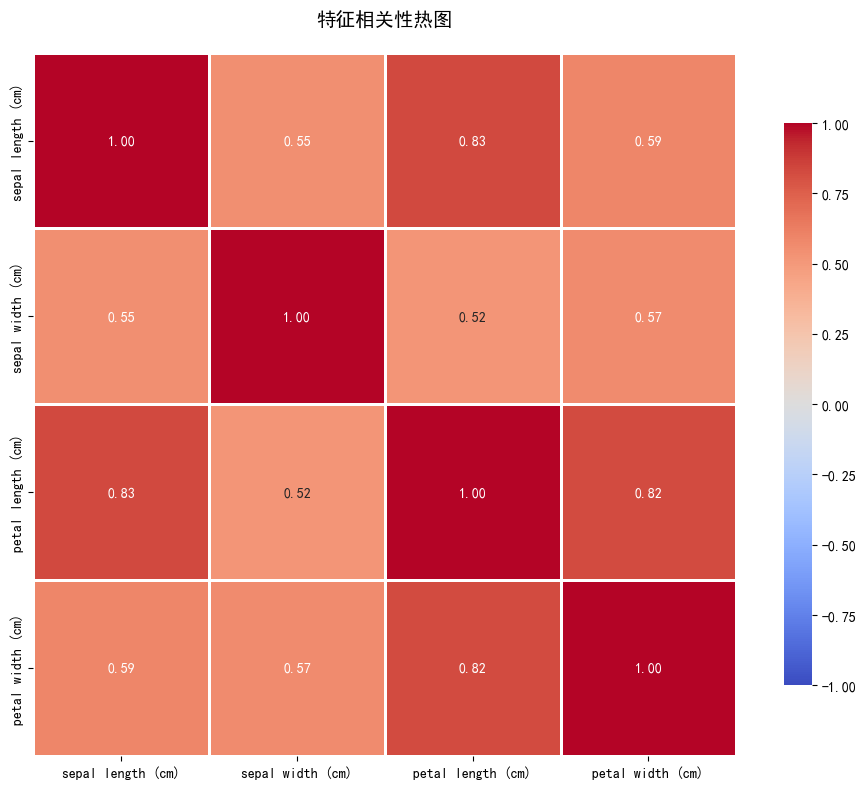


相关性分析说明:
- 相关系数范围: -1 到 1
- 接近 1: 强正相关（一个增加，另一个也增加）
- 接近 -1: 强负相关（一个增加，另一个减少）
- 接近 0: 无明显相关性


In [ ]:
# 计算特征之间的相关系数
correlation_matrix = df.iloc[:, :-1].corr()

# 绘制相关性热图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', vmin=-1, vmax=1)
plt.title('特征相关性热图', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n相关性分析说明:")
print("- 相关系数范围: -1 到 1")
print("- 接近 1: 强正相关（一个增加，另一个也增加）")
print("- 接近 -1: 强负相关（一个增加，另一个减少）")
print("- 接近 0: 无明显相关性")

### 3.3 数据分布可视化

In [ ]:
# 创建DataFrame便于可视化
df = pd.DataFrame(X_binary, columns=iris.feature_names)
df['species'] = ['Versicolor' if i == 0 else 'Virginica' for i in y_binary]

# 显示前几行数据
print("数据预览:")
df.head()

数据预览:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,7.0,3.2,4.7,1.4,Versicolor
1,6.4,3.2,4.5,1.5,Versicolor
2,6.9,3.1,4.9,1.5,Versicolor
3,5.5,2.3,4.0,1.3,Versicolor
4,6.5,2.8,4.6,1.5,Versicolor


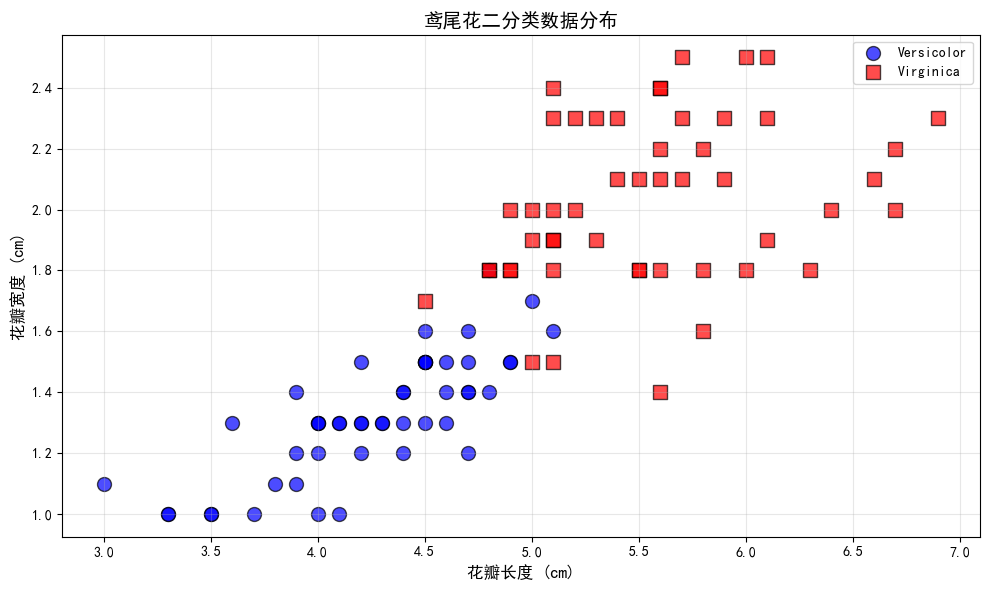

In [ ]:
# 绘制散点图
plt.figure(figsize=(10, 6))
colors = ['blue', 'red']
markers = ['o', 's']
labels = ['Versicolor', 'Virginica']

for i in range(2):
    mask = y_binary == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                c=colors[i], marker=markers[i], 
                label=labels[i], alpha=0.7, s=100, edgecolors='black')

plt.xlabel('花瓣长度 (cm)', fontsize=12)
plt.ylabel('花瓣宽度 (cm)', fontsize=12)
plt.title('鸢尾花二分类数据分布', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. 划分训练集和测试集

In [ ]:
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

训练集大小: 70
测试集大小: 30


### 5. 训练逻辑回归模型

In [ ]:
# 创建并训练逻辑回归模型
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 评估模型
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"训练集准确率: {train_accuracy:.4f}")
print(f"测试集准确率: {test_accuracy:.4f}")
print(f"\n模型参数:")
print(f"权重: {model.coef_[0]}")
print(f"截距: {model.intercept_[0]:.4f}")

训练集准确率: 0.9429
测试集准确率: 0.9333

模型参数:
权重: [2.46684889 2.21558316]
截距: -15.8323


### 6. 混淆矩阵

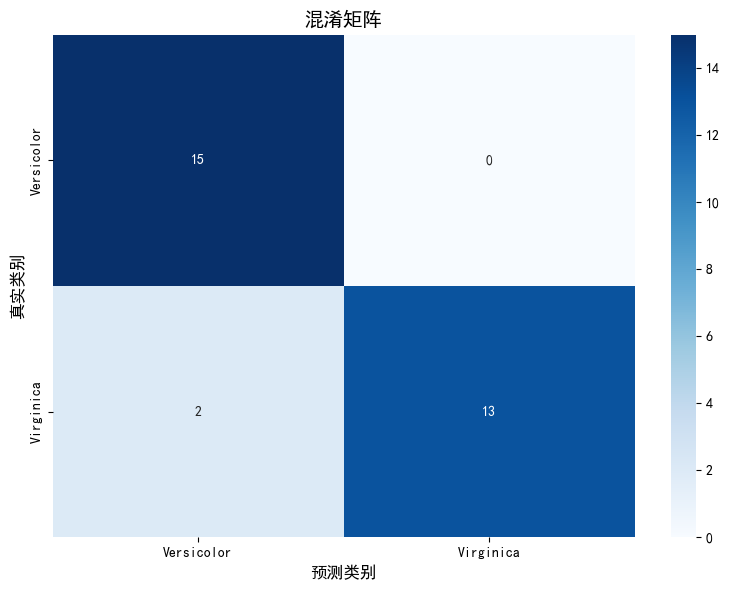


分类报告:
              precision    recall  f1-score   support

  Versicolor       0.88      1.00      0.94        15
   Virginica       1.00      0.87      0.93        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [ ]:
# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Versicolor', 'Virginica'],
            yticklabels=['Versicolor', 'Virginica'])
plt.xlabel('预测类别', fontsize=12)
plt.ylabel('真实类别', fontsize=12)
plt.title('混淆矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 详细分类报告
print("\n分类报告:")
print(classification_report(y_test, y_test_pred, target_names=['Versicolor', 'Virginica']))

### 6.1 ROC曲线和AUC评分

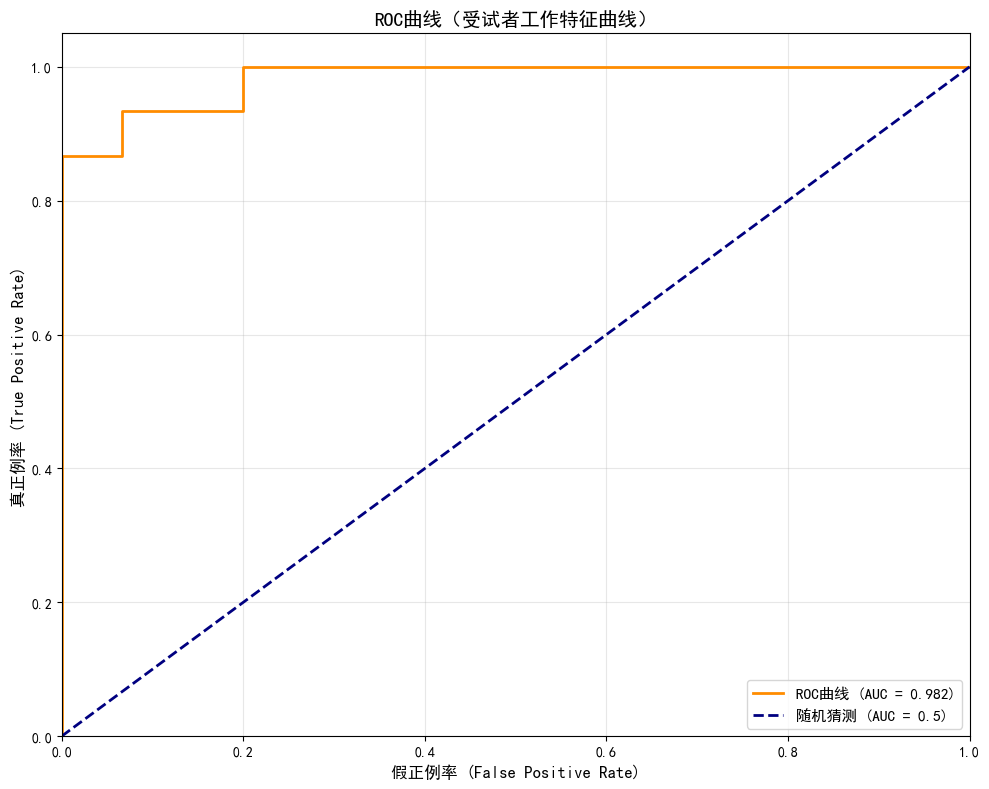


AUC评分解释:
训练集 AUC: 0.9935
测试集 AUC: 0.9822

AUC = 1.0: 完美分类器
AUC = 0.5: 随机猜测
AUC > 0.9: 优秀模型
0.8 < AUC < 0.9: 良好模型
0.7 < AUC < 0.8: 一般模型


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 获取预测概率
y_test_proba = model.predict_proba(X_test)[:, 1]
y_train_proba = model.predict_proba(X_train)[:, 1]

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# 绘制ROC曲线
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC曲线 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='随机猜测 (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正例率 (False Positive Rate)', fontsize=12)
plt.ylabel('真正例率 (True Positive Rate)', fontsize=12)
plt.title('ROC曲线（受试者工作特征曲线）', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC评分解释:")
print(f"训练集 AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"测试集 AUC: {roc_auc:.4f}")
print(f"\nAUC = 1.0: 完美分类器")
print(f"AUC = 0.5: 随机猜测")
print(f"AUC > 0.9: 优秀模型")
print(f"0.8 < AUC < 0.9: 良好模型")
print(f"0.7 < AUC < 0.8: 一般模型")

### 6.2 学习曲线分析

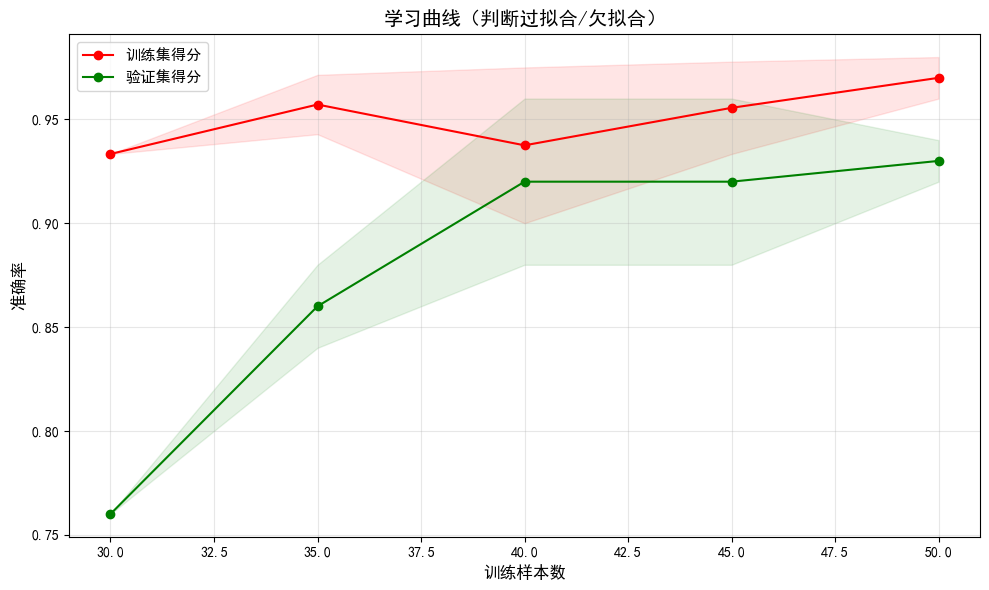

学习曲线分析 - 诊断报告

📊 关键性能指标：
  训练集最终准确率: 0.9700 (±0.0100)
  验证集最终准确率: 0.9300 (±0.0100)
  准确率差距: 0.0400

📈 学习曲线趋势：
  训练集改进: +0.0367
  验证集改进: +0.1700

🔍 模型诊断：
--------------------------------------------------------------------------------
✅ 【拟合良好】- 模型表现优秀
   症状: 验证集准确率高(93.00%)，且与训练集差距小(0.0400)
   特点: 
      • 模型复杂度与数据复杂度相匹配
      • 泛化性能强，适应未来数据
      • 无明显过拟合或欠拟合现象

【指标含义说明】

✓ 训练集准确率：模型在已见过的数据上的表现
  - 高 → 模型学到了训练数据的规律
  - 过高 → 可能过拟合

✓ 验证集准确率：模型在未见过的数据上的表现（真实泛化能力）
  - 这是最重要的指标！
  - 高 → 模型泛化能力强，可应用于新数据
  - 低 → 模型可能欠拟合或特征不足

✓ 准确率差距（Gap = 训练 - 验证）：过拟合程度
  - Gap < 0.05  → 优秀（完美平衡）
  - Gap 0.05-0.1 → 良好（可接受）
  - Gap 0.1-0.2  → 一般（有过拟合倾向）
  - Gap > 0.2    → 严重过拟合（需要改进）

✓ 标准差（±xx）：模型稳定性
  - 小 → 模型稳定，不同数据分割结果相近
  - 大 → 模型不稳定，对数据分割敏感



In [11]:
from sklearn.model_selection import learning_curve, StratifiedKFold

# 计算学习曲线
# 样本量较小，训练集比例过低时可能只包含单一类别
# 这里提高最小训练比例，避免出现单类训练集
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(random_state=42), 
    X_2d, y_binary, 
    train_sizes=np.linspace(0.6, 1.0, 5),  # 最小训练比例提高到 0.6
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# 计算均值和标准差
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# 绘制学习曲线
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='训练集得分')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='验证集得分')

# 填充标准差区域
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='r')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.1, color='g')

plt.xlabel('训练样本数', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.title('学习曲线（判断过拟合/欠拟合）', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 详细的学习曲线分析
print("="*80)
print("学习曲线分析 - 诊断报告")
print("="*80)

# 计算关键指标
train_final = train_mean[-1]
val_final = val_mean[-1]
gap = train_final - val_final
train_std_final = train_std[-1]
val_std_final = val_std[-1]

print(f"\n📊 关键性能指标：")
print(f"  训练集最终准确率: {train_final:.4f} (±{train_std_final:.4f})")
print(f"  验证集最终准确率: {val_final:.4f} (±{val_std_final:.4f})")
print(f"  准确率差距: {gap:.4f}")

print(f"\n📈 学习曲线趋势：")
if len(train_mean) > 1:
    train_improvement = train_mean[-1] - train_mean[0]
    val_improvement = val_mean[-1] - val_mean[0]
    print(f"  训练集改进: {train_improvement:+.4f}")
    print(f"  验证集改进: {val_improvement:+.4f}")

# 诊断过拟合/欠拟合
print(f"\n🔍 模型诊断：")
print("-" * 80)

if val_final < 0.7:
    print(f"⚠️  【欠拟合风险】- 验证集准确率较低 ({val_final:.2%})")
    print(f"   症状: 验证集准确率未达到0.7的基准线")
    print(f"   原因: ")
    print(f"      • 模型过于简单，无法捕捉数据的复杂规律")
    print(f"      • 训练数据不足")
    print(f"      • 特征信息量不够")
    print(f"   改进方案: ")
    print(f"      → 增加模型复杂度（如使用多项式特征）")
    print(f"      → 收集更多训练数据")
    print(f"      → 进行特征工程，提取更有判别力的特征")
    print(f"      → 调整学习率或增加训练轮数")
elif gap > 0.1:
    print(f"⚠️  【过拟合风险】- 训练集与验证集差距较大 ({gap:.4f})")
    print(f"   症状: 训练准确率({train_final:.2%}) >> 验证准确率({val_final:.2%})")
    print(f"   原因: ")
    print(f"      • 模型过于复杂，记住了训练数据的噪声")
    print(f"      • 训练数据量不足相对于模型复杂度")
    print(f"      • 没有进行正则化处理")
    print(f"   改进方案: ")
    print(f"      → 简化模型（减少特征或降低复杂度）")
    print(f"      → 增加L1/L2正则化")
    print(f"      → 增加数据样本量")
    print(f"      → 使用早停法（Early Stopping）")
    print(f"      → 数据增强或降噪")
elif val_final > 0.85:
    print(f"✅ 【拟合良好】- 模型表现优秀")
    print(f"   症状: 验证集准确率高({val_final:.2%})，且与训练集差距小({gap:.4f})")
    print(f"   特点: ")
    print(f"      • 模型复杂度与数据复杂度相匹配")
    print(f"      • 泛化性能强，适应未来数据")
    print(f"      • 无明显过拟合或欠拟合现象")
else:
    print(f"✓ 【正常拟合】- 模型状态可接受")
    print(f"   症状: 验证集准确率中等({val_final:.2%})，差距合理({gap:.4f})")
    print(f"   特点: ")
    print(f"      • 模型有一定的改进空间")
    print(f"      • 可考虑微调参数进一步提升")

print("\n" + "="*80)
print("【指标含义说明】")
print("="*80)
print("""
✓ 训练集准确率：模型在已见过的数据上的表现
  - 高 → 模型学到了训练数据的规律
  - 过高 → 可能过拟合

✓ 验证集准确率：模型在未见过的数据上的表现（真实泛化能力）
  - 这是最重要的指标！
  - 高 → 模型泛化能力强，可应用于新数据
  - 低 → 模型可能欠拟合或特征不足

✓ 准确率差距（Gap = 训练 - 验证）：过拟合程度
  - Gap < 0.05  → 优秀（完美平衡）
  - Gap 0.05-0.1 → 良好（可接受）
  - Gap 0.1-0.2  → 一般（有过拟合倾向）
  - Gap > 0.2    → 严重过拟合（需要改进）

✓ 标准差（±xx）：模型稳定性
  - 小 → 模型稳定，不同数据分割结果相近
  - 大 → 模型不稳定，对数据分割敏感
""")
print("="*80)

### 7. 绘制决策边界和逻辑回归曲线

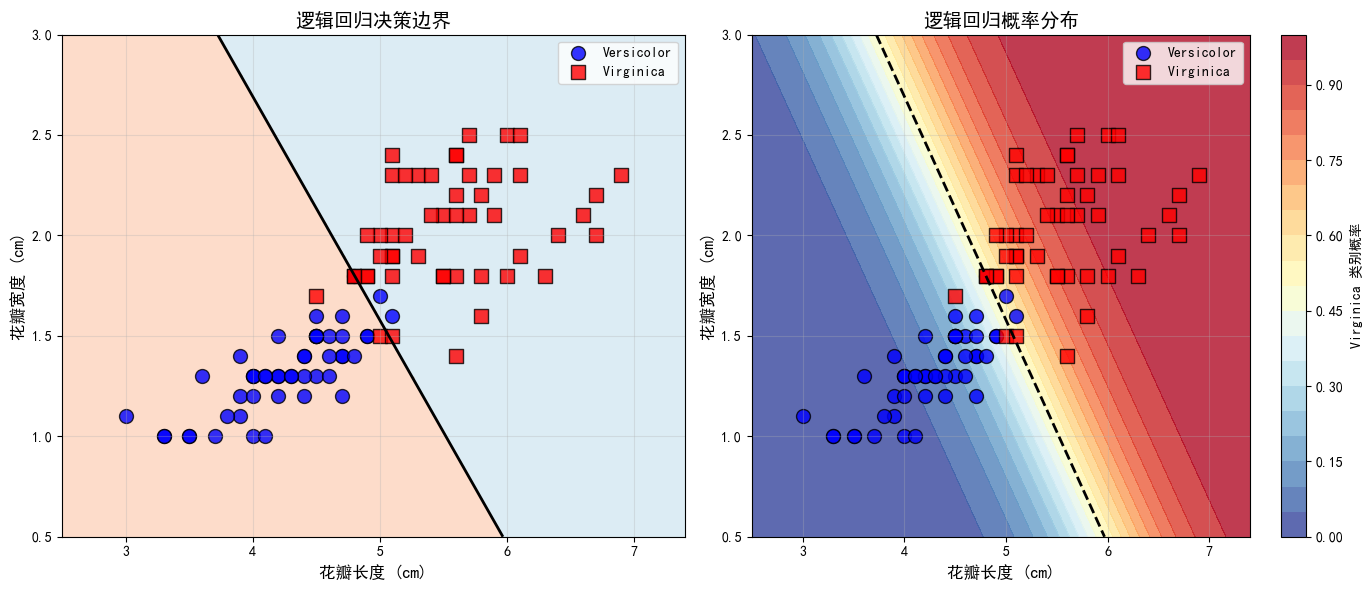

In [ ]:
# 创建网格用于绘制决策边界
def plot_decision_boundary(model, X, y):
    # 设置网格边界
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 创建网格
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # 预测每个网格点的类别
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 获取概率
    Z_proba = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z_proba = Z_proba.reshape(xx.shape)
    
    # 绘制决策边界
    plt.figure(figsize=(14, 6))
    
    # 子图1：决策边界
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu', levels=1)
    plt.contour(xx, yy, Z_proba, levels=[0.5], colors='black', linewidths=2)
    
    # 绘制数据点
    colors = ['blue', 'red']
    markers = ['o', 's']
    labels = ['Versicolor', 'Virginica']
    
    for i in range(2):
        mask = y == i
        plt.scatter(X[mask, 0], X[mask, 1], 
                    c=colors[i], marker=markers[i], 
                    label=labels[i], alpha=0.8, s=100, edgecolors='black')
    
    plt.xlabel('花瓣长度 (cm)', fontsize=12)
    plt.ylabel('花瓣宽度 (cm)', fontsize=12)
    plt.title('逻辑回归决策边界', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # 子图2：概率热图
    plt.subplot(1, 2, 2)
    contour = plt.contourf(xx, yy, Z_proba, alpha=0.8, cmap='RdYlBu_r', levels=20)
    plt.colorbar(contour, label='Virginica 类别概率')
    plt.contour(xx, yy, Z_proba, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    # 绘制数据点
    for i in range(2):
        mask = y == i
        plt.scatter(X[mask, 0], X[mask, 1], 
                    c=colors[i], marker=markers[i], 
                    label=labels[i], alpha=0.8, s=100, edgecolors='black')
    
    plt.xlabel('花瓣长度 (cm)', fontsize=12)
    plt.ylabel('花瓣宽度 (cm)', fontsize=12)
    plt.title('逻辑回归概率分布', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 绘制决策边界
plot_decision_boundary(model, X_2d, y_binary)

### 8. Sigmoid函数可视化（逻辑回归曲线）

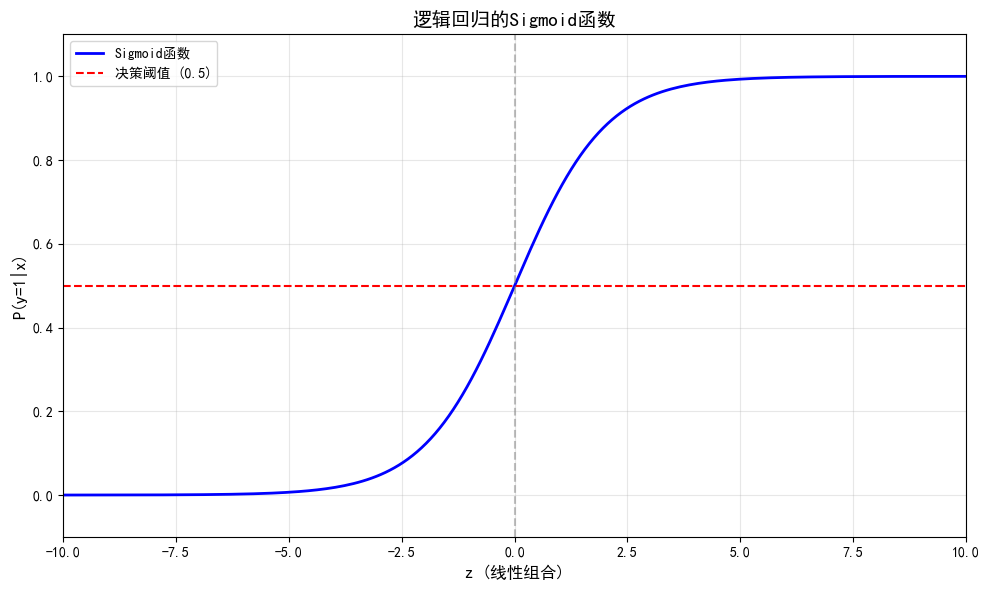

Sigmoid函数特点:
- 当 z → +∞ 时，σ(z) → 1
- 当 z → -∞ 时，σ(z) → 0
- 当 z = 0 时，σ(z) = 0.5
- 函数输出范围: (0, 1)


In [ ]:
# 绘制Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
y_sigmoid = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, y_sigmoid, 'b-', linewidth=2, label='Sigmoid函数')
plt.axhline(y=0.5, color='r', linestyle='--', label='决策阈值 (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z (线性组合)', fontsize=12)
plt.ylabel('P(y=1|x)', fontsize=12)
plt.title('逻辑回归的Sigmoid函数', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(-10, 10)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

print("Sigmoid函数特点:")
print("- 当 z → +∞ 时，σ(z) → 1")
print("- 当 z → -∞ 时，σ(z) → 0")
print("- 当 z = 0 时，σ(z) = 0.5")
print("- 函数输出范围: (0, 1)")

### 9. 特征重要性分析

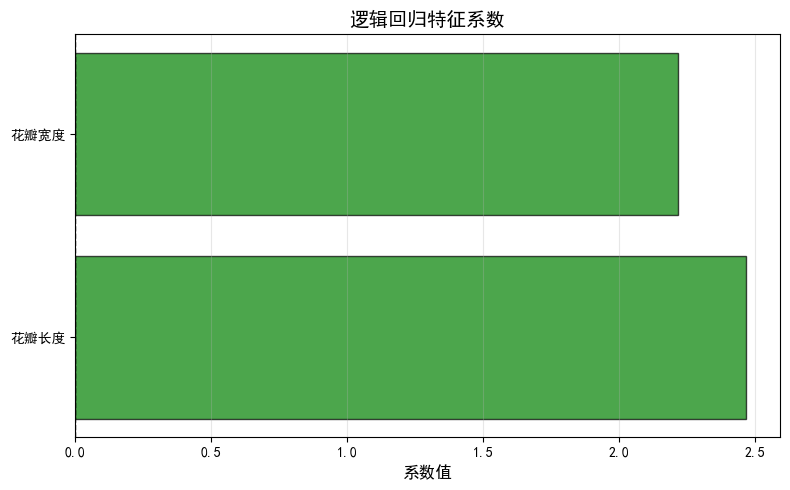


特征系数解释:
花瓣长度: 2.4668
花瓣宽度: 2.2156


In [ ]:
# 绘制特征重要性
feature_names = ['花瓣长度', '花瓣宽度']
coefficients = model.coef_[0]

plt.figure(figsize=(8, 5))
colors_bar = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors_bar, alpha=0.7, edgecolor='black')
plt.xlabel('系数值', fontsize=12)
plt.title('逻辑回归特征系数', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n特征系数解释:")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

### 10. 实验总结

In [ ]:
print("="*60)
print("鸢尾花二分类实验总结")
print("="*60)
print(f"数据集: 鸢尾花数据集 (Versicolor vs Virginica)")
print(f"样本总数: {len(y_binary)}")
print(f"特征数量: 2 (花瓣长度, 花瓣宽度)")
print(f"\n模型: 逻辑回归 (Logistic Regression)")
print(f"训练集准确率: {train_accuracy:.2%}")
print(f"测试集准确率: {test_accuracy:.2%}")
print(f"\n模型参数:")
print(f"  权重 w1 (花瓣长度): {model.coef_[0][0]:.4f}")
print(f"  权重 w2 (花瓣宽度): {model.coef_[0][1]:.4f}")
print(f"  截距 b: {model.intercept_[0]:.4f}")
print(f"\n决策函数: z = {model.coef_[0][0]:.4f}*x1 + {model.coef_[0][1]:.4f}*x2 + {model.intercept_[0]:.4f}")
print(f"预测概率: P(y=1|x) = 1 / (1 + exp(-z))")
print("="*60)

鸢尾花二分类实验总结
数据集: 鸢尾花数据集 (Versicolor vs Virginica)
样本总数: 100
特征数量: 2 (花瓣长度, 花瓣宽度)

模型: 逻辑回归 (Logistic Regression)
训练集准确率: 94.29%
测试集准确率: 93.33%

模型参数:
  权重 w1 (花瓣长度): 2.4668
  权重 w2 (花瓣宽度): 2.2156
  截距 b: -15.8323

决策函数: z = 2.4668*x1 + 2.2156*x2 + -15.8323
预测概率: P(y=1|x) = 1 / (1 + exp(-z))


---
## 学习总结与思考题

### 11. 思考题（初学者练习）

通过以上实验，思考以下问题：

#### 基础理解题：
1. **Sigmoid函数的作用是什么？** 为什么逻辑回归需要用它？
2. **混淆矩阵中的哪些指标最重要？** 如何从混淆矩阵计算准确率？
3. **ROC曲线下的面积(AUC)代表什么？** AUC=0.5和AUC=1.0分别意味着什么？

#### 实验分析题：
4. **为什么花瓣长度和花瓣宽度能有效区分两种鸢尾花？** 观察数据分布图得出你的结论。
5. **从学习曲线可以看出模型是否过拟合？** 如果过拟合了，应该如何改进？
6. **使用4个特征比只用2个特征准确率提升了多少？** 是否特征越多越好？